PWM5 - vent

Fit results:
cubic        | RMSE = 1.682405 | R^2 = 0.999612 | params = [ 0.05938291 -0.27988543 24.20478979 -0.52522611]
exponential  | RMSE = 1.995094 | R^2 = 0.999454 | params = [ 5.17120091e+02  4.19465232e-02 -5.16660699e+02]
quadratic    | RMSE = 2.088157 | R^2 = 0.999402 | params = [ 0.54560584 21.42698364  0.48297127]
power        | RMSE = 2.433162 | R^2 = 0.999188 | params = [ 16.07546626   1.19593431 -15.26900685]
linear       | RMSE = 5.162307 | R^2 = 0.996345 | params = [26.55504324 -5.91636311]

Best model: cubic
Best parameters: [ 0.05938291 -0.27988543 24.20478979 -0.52522611]


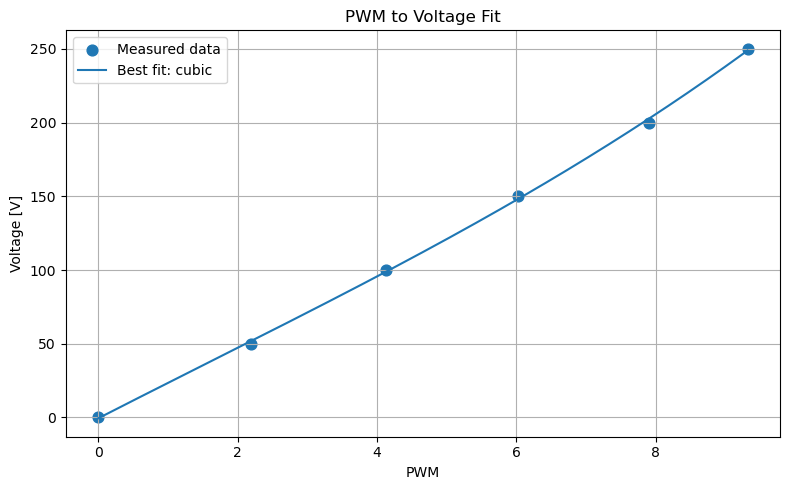

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Replace these arrays with your 5 measured points
x_data = np.array([0.0, 2.19, 4.13, 6.03, 7.91, 9.32], dtype=float)
y_data = np.array([0, 50, 100, 150, 200, 250], dtype=float)


def linear(x, a, b):
    return a * x + b


def quadratic(x, a, b, c):
    return a * x**2 + b * x + c


def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d


def power_model(x, a, b, c):
    return a * np.power(x + 1.0, b) + c


def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0
    return 1.0 - ss_res / ss_tot


models = {
    "linear": (linear, [1.0, 0.0]),
    "quadratic": (quadratic, [0.0, 1.0, 0.0]),
    "cubic": (cubic, [0.0, 0.0, 1.0, 0.0]),
    "power": (power_model, [1.0, 1.0, 0.0]),
    "exponential": (exp_model, [1.0, 0.001, 0.0]),
}

results = []

for name, (func, p0) in models.items():
    try:
        popt, _ = curve_fit(func, x_data, y_data, p0=p0, maxfev=100000)
        y_fit = func(x_data, *popt)
        model_rmse = rmse(y_data, y_fit)
        model_r2 = r2_score(y_data, y_fit)

        results.append({
            "name": name,
            "func": func,
            "params": popt,
            "rmse": model_rmse,
            "r2": model_r2,
        })
    except Exception as e:
        print(f"Model {name} failed: {e}")

if not results:
    raise RuntimeError("No model could be fitted to the data.")

results.sort(key=lambda item: item["rmse"])
best = results[0]

print("Fit results:")
for item in results:
    print(f"{item['name']:12s} | RMSE = {item['rmse']:.6f} | R^2 = {item['r2']:.6f} | params = {item['params']}")

print("\nBest model:", best["name"])
print("Best parameters:", best["params"])


def pwm_to_voltage(x):
    x = np.asarray(x, dtype=float)
    y = best["func"](x, *best["params"])
    return y


# Plot data and best fitted curve
x_plot = np.linspace(np.min(x_data), np.max(x_data), 400)
y_plot = pwm_to_voltage(x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, label="Measured data", s=60)
plt.plot(x_plot, y_plot, label=f"Best fit: {best['name']}")
plt.xlabel("PWM")
plt.ylabel("Voltage [V]")
plt.title("PWM to Voltage Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

PWM 6 - spir

Fit results:
cubic        | RMSE = 2.347938 | R^2 = 0.999244 | params = [ 0.08732906 -0.39322033 22.8496962  -0.61564759]
exponential  | RMSE = 2.736661 | R^2 = 0.998973 | params = [ 3.04767288e+02  6.36609506e-02 -3.04075904e+02]
quadratic    | RMSE = 2.945766 | R^2 = 0.998810 | params = [ 0.81738861 18.8000468   0.74443439]
power        | RMSE = 3.391911 | R^2 = 0.998422 | params = [ 12.25727173   1.30386844 -11.05608506]
linear       | RMSE = 7.649261 | R^2 = 0.991976 | params = [26.49103177 -8.82386208]

Best model: cubic
Best parameters: [ 0.08732906 -0.39322033 22.8496962  -0.61564759]


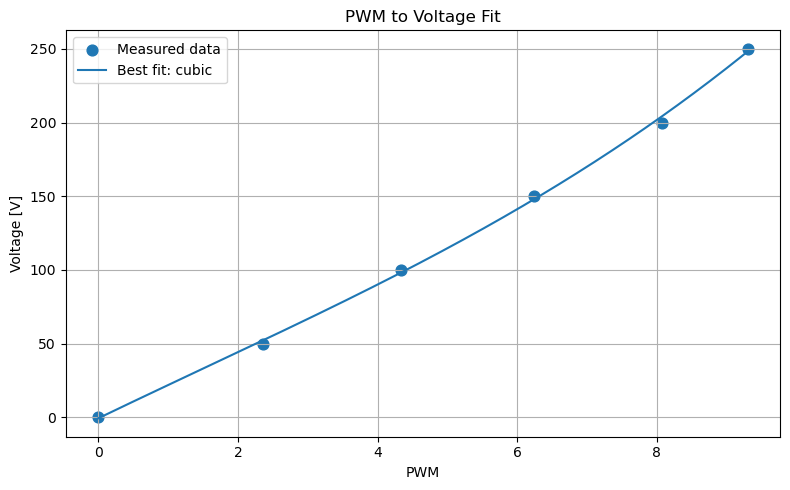

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Replace these arrays with your 5 measured points
x_data = np.array([0.0, 2.36, 4.34, 6.24, 8.07, 9.3], dtype=float)
y_data = np.array([0, 50, 100, 150, 200, 250], dtype=float)


def linear(x, a, b):
    return a * x + b


def quadratic(x, a, b, c):
    return a * x**2 + b * x + c


def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d


def power_model(x, a, b, c):
    return a * np.power(x + 1.0, b) + c


def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0
    return 1.0 - ss_res / ss_tot


models = {
    "linear": (linear, [1.0, 0.0]),
    "quadratic": (quadratic, [0.0, 1.0, 0.0]),
    "cubic": (cubic, [0.0, 0.0, 1.0, 0.0]),
    "power": (power_model, [1.0, 1.0, 0.0]),
    "exponential": (exp_model, [1.0, 0.001, 0.0]),
}

results = []

for name, (func, p0) in models.items():
    try:
        popt, _ = curve_fit(func, x_data, y_data, p0=p0, maxfev=100000)
        y_fit = func(x_data, *popt)
        model_rmse = rmse(y_data, y_fit)
        model_r2 = r2_score(y_data, y_fit)

        results.append({
            "name": name,
            "func": func,
            "params": popt,
            "rmse": model_rmse,
            "r2": model_r2,
        })
    except Exception as e:
        print(f"Model {name} failed: {e}")

if not results:
    raise RuntimeError("No model could be fitted to the data.")

results.sort(key=lambda item: item["rmse"])
best = results[0]

print("Fit results:")
for item in results:
    print(f"{item['name']:12s} | RMSE = {item['rmse']:.6f} | R^2 = {item['r2']:.6f} | params = {item['params']}")

print("\nBest model:", best["name"])
print("Best parameters:", best["params"])


def pwm_to_voltage(x):
    x = np.asarray(x, dtype=float)
    y = best["func"](x, *best["params"])
    return y


# Plot data and best fitted curve
x_plot = np.linspace(np.min(x_data), np.max(x_data), 400)
y_plot = pwm_to_voltage(x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, label="Measured data", s=60)
plt.plot(x_plot, y_plot, label=f"Best fit: {best['name']}")
plt.xlabel("PWM")
plt.ylabel("Voltage [V]")
plt.title("PWM to Voltage Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

A1 - snimac 1

Fit results:
cubic        | RMSE = 0.009106 | R^2 = 0.999993 | params = [ 4.64044633e-10 -8.44254606e-07  1.02946107e-02  5.87859135e-05]
power        | RMSE = 0.011215 | R^2 = 0.999989 | params = [ 0.01087302  0.98641949 -0.00942471]
quadratic    | RMSE = 0.013253 | R^2 = 0.999985 | params = [-1.93158099e-07  1.00843807e-02  4.43037486e-03]
linear       | RMSE = 0.022766 | R^2 = 0.999955 | params = [0.0098881  0.03118617]
exponential  | RMSE = 0.022879 | R^2 = 0.999954 | params = [ 3.35349213e+04  2.94815306e-07 -3.35348899e+04]

Best model: cubic
Best parameters: [ 4.64044633e-10 -8.44254606e-07  1.02946107e-02  5.87859135e-05]

Example conversion:
PWM =    0.0 -> U = 0.0001 V
PWM =   32.0 -> U = 0.3286 V
PWM =   64.0 -> U = 0.6556 V
PWM =  128.0 -> U = 1.3049 V
PWM =  200.0 -> U = 2.0289 V
PWM =  255.0 -> U = 2.5780 V


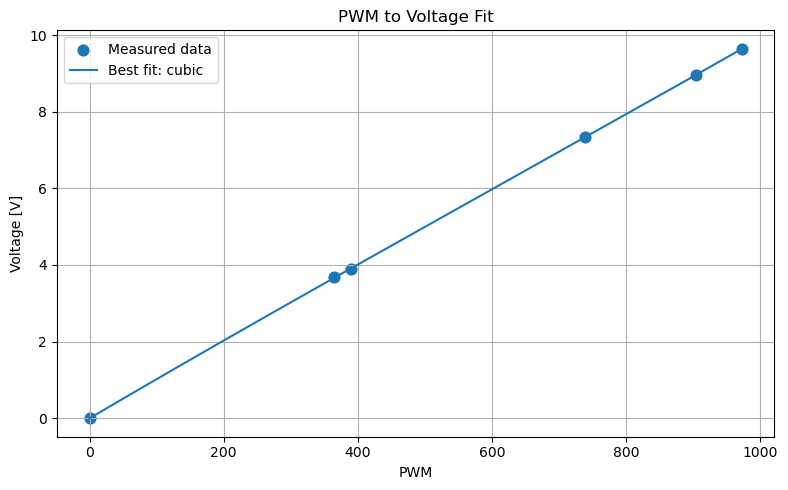

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Replace these arrays with your 5 measured points
x_data = np.array([0.0, 365, 390, 739, 904, 972], dtype=float)
y_data = np.array([0.0, 3.68, 3.9, 7.34, 8.95, 9.64], dtype=float)


def linear(x, a, b):
    return a * x + b


def quadratic(x, a, b, c):
    return a * x**2 + b * x + c


def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d


def power_model(x, a, b, c):
    return a * np.power(x + 1.0, b) + c


def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0
    return 1.0 - ss_res / ss_tot


models = {
    "linear": (linear, [1.0, 0.0]),
    "quadratic": (quadratic, [0.0, 1.0, 0.0]),
    "cubic": (cubic, [0.0, 0.0, 1.0, 0.0]),
    "power": (power_model, [1.0, 1.0, 0.0]),
    "exponential": (exp_model, [1.0, 0.001, 0.0]),
}

results = []

for name, (func, p0) in models.items():
    try:
        popt, _ = curve_fit(func, x_data, y_data, p0=p0, maxfev=100000)
        y_fit = func(x_data, *popt)
        model_rmse = rmse(y_data, y_fit)
        model_r2 = r2_score(y_data, y_fit)

        results.append({
            "name": name,
            "func": func,
            "params": popt,
            "rmse": model_rmse,
            "r2": model_r2,
        })
    except Exception as e:
        print(f"Model {name} failed: {e}")

if not results:
    raise RuntimeError("No model could be fitted to the data.")

results.sort(key=lambda item: item["rmse"])
best = results[0]

print("Fit results:")
for item in results:
    print(f"{item['name']:12s} | RMSE = {item['rmse']:.6f} | R^2 = {item['r2']:.6f} | params = {item['params']}")

print("\nBest model:", best["name"])
print("Best parameters:", best["params"])


def pwm_to_voltage(x):
    x = np.asarray(x, dtype=float)
    y = best["func"](x, *best["params"])
    return y


# Plot data and best fitted curve
x_plot = np.linspace(np.min(x_data), np.max(x_data), 400)
y_plot = pwm_to_voltage(x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, label="Measured data", s=60)
plt.plot(x_plot, y_plot, label=f"Best fit: {best['name']}")
plt.xlabel("PWM")
plt.ylabel("Voltage [V]")
plt.title("PWM to Voltage Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

A2 - snimac 2

Fit results:
cubic        | RMSE = 0.022288 | R^2 = 0.999931 | params = [-9.09109415e-10  8.99002333e-07  9.78867803e-03 -9.65193864e-05]
quadratic    | RMSE = 0.023101 | R^2 = 0.999925 | params = [-1.64599425e-07  1.00778748e-02 -1.34578787e-03]
power        | RMSE = 0.023359 | R^2 = 0.999924 | params = [ 0.01055632  0.99114487 -0.01129147]
linear       | RMSE = 0.025394 | R^2 = 0.999910 | params = [0.00994566 0.01187926]
exponential  | RMSE = 0.025474 | R^2 = 0.999909 | params = [ 1.67286345e+04  5.94386915e-07 -1.67286224e+04]

Best model: cubic
Best parameters: [-9.09109415e-10  8.99002333e-07  9.78867803e-03 -9.65193864e-05]


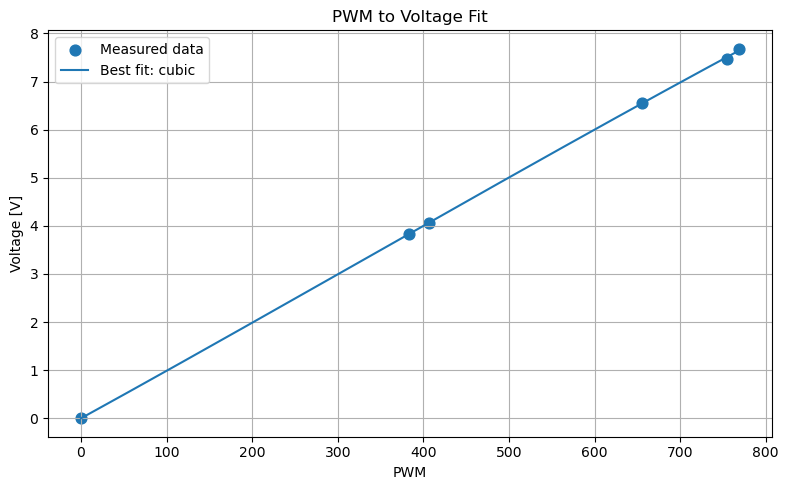

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Replace these arrays with your 5 measured points
x_data = np.array([0, 383, 406, 655, 755, 769], dtype=float)
y_data = np.array([0.0, 3.83, 4.06, 6.55, 7.47, 7.68], dtype=float)


def linear(x, a, b):
    return a * x + b


def quadratic(x, a, b, c):
    return a * x**2 + b * x + c


def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d


def power_model(x, a, b, c):
    return a * np.power(x + 1.0, b) + c


def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0
    return 1.0 - ss_res / ss_tot


models = {
    "linear": (linear, [1.0, 0.0]),
    "quadratic": (quadratic, [0.0, 1.0, 0.0]),
    "cubic": (cubic, [0.0, 0.0, 1.0, 0.0]),
    "power": (power_model, [1.0, 1.0, 0.0]),
    "exponential": (exp_model, [1.0, 0.001, 0.0]),
}

results = []

for name, (func, p0) in models.items():
    try:
        popt, _ = curve_fit(func, x_data, y_data, p0=p0, maxfev=100000)
        y_fit = func(x_data, *popt)
        model_rmse = rmse(y_data, y_fit)
        model_r2 = r2_score(y_data, y_fit)

        results.append({
            "name": name,
            "func": func,
            "params": popt,
            "rmse": model_rmse,
            "r2": model_r2,
        })
    except Exception as e:
        print(f"Model {name} failed: {e}")

if not results:
    raise RuntimeError("No model could be fitted to the data.")

results.sort(key=lambda item: item["rmse"])
best = results[0]

print("Fit results:")
for item in results:
    print(f"{item['name']:12s} | RMSE = {item['rmse']:.6f} | R^2 = {item['r2']:.6f} | params = {item['params']}")

print("\nBest model:", best["name"])
print("Best parameters:", best["params"])


def pwm_to_voltage(x):
    x = np.asarray(x, dtype=float)
    y = best["func"](x, *best["params"])
    return y



# Plot data and best fitted curve
x_plot = np.linspace(np.min(x_data), np.max(x_data), 400)
y_plot = pwm_to_voltage(x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, label="Measured data", s=60)
plt.plot(x_plot, y_plot, label=f"Best fit: {best['name']}")
plt.xlabel("PWM")
plt.ylabel("Voltage [V]")
plt.title("PWM to Voltage Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()